In [2]:
%pip install kagglehub

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 15.2 MB/s eta 0:00:00
Using cached idna-3.10-py3-none-any.whl (70 kB)
Using cached urllib3-2.5.0-py3-none-any.whl (129 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [kagglehub]/8 [idna]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

/home/jh.sim/miniconda3/envs/ai_lecture/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.29G/2.29G [01:27<00:00, 28.2MB/s]


Extracting files...
Path to dataset files: /home/jh.sim/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


['NORMAL', 'PNEUMONIA']


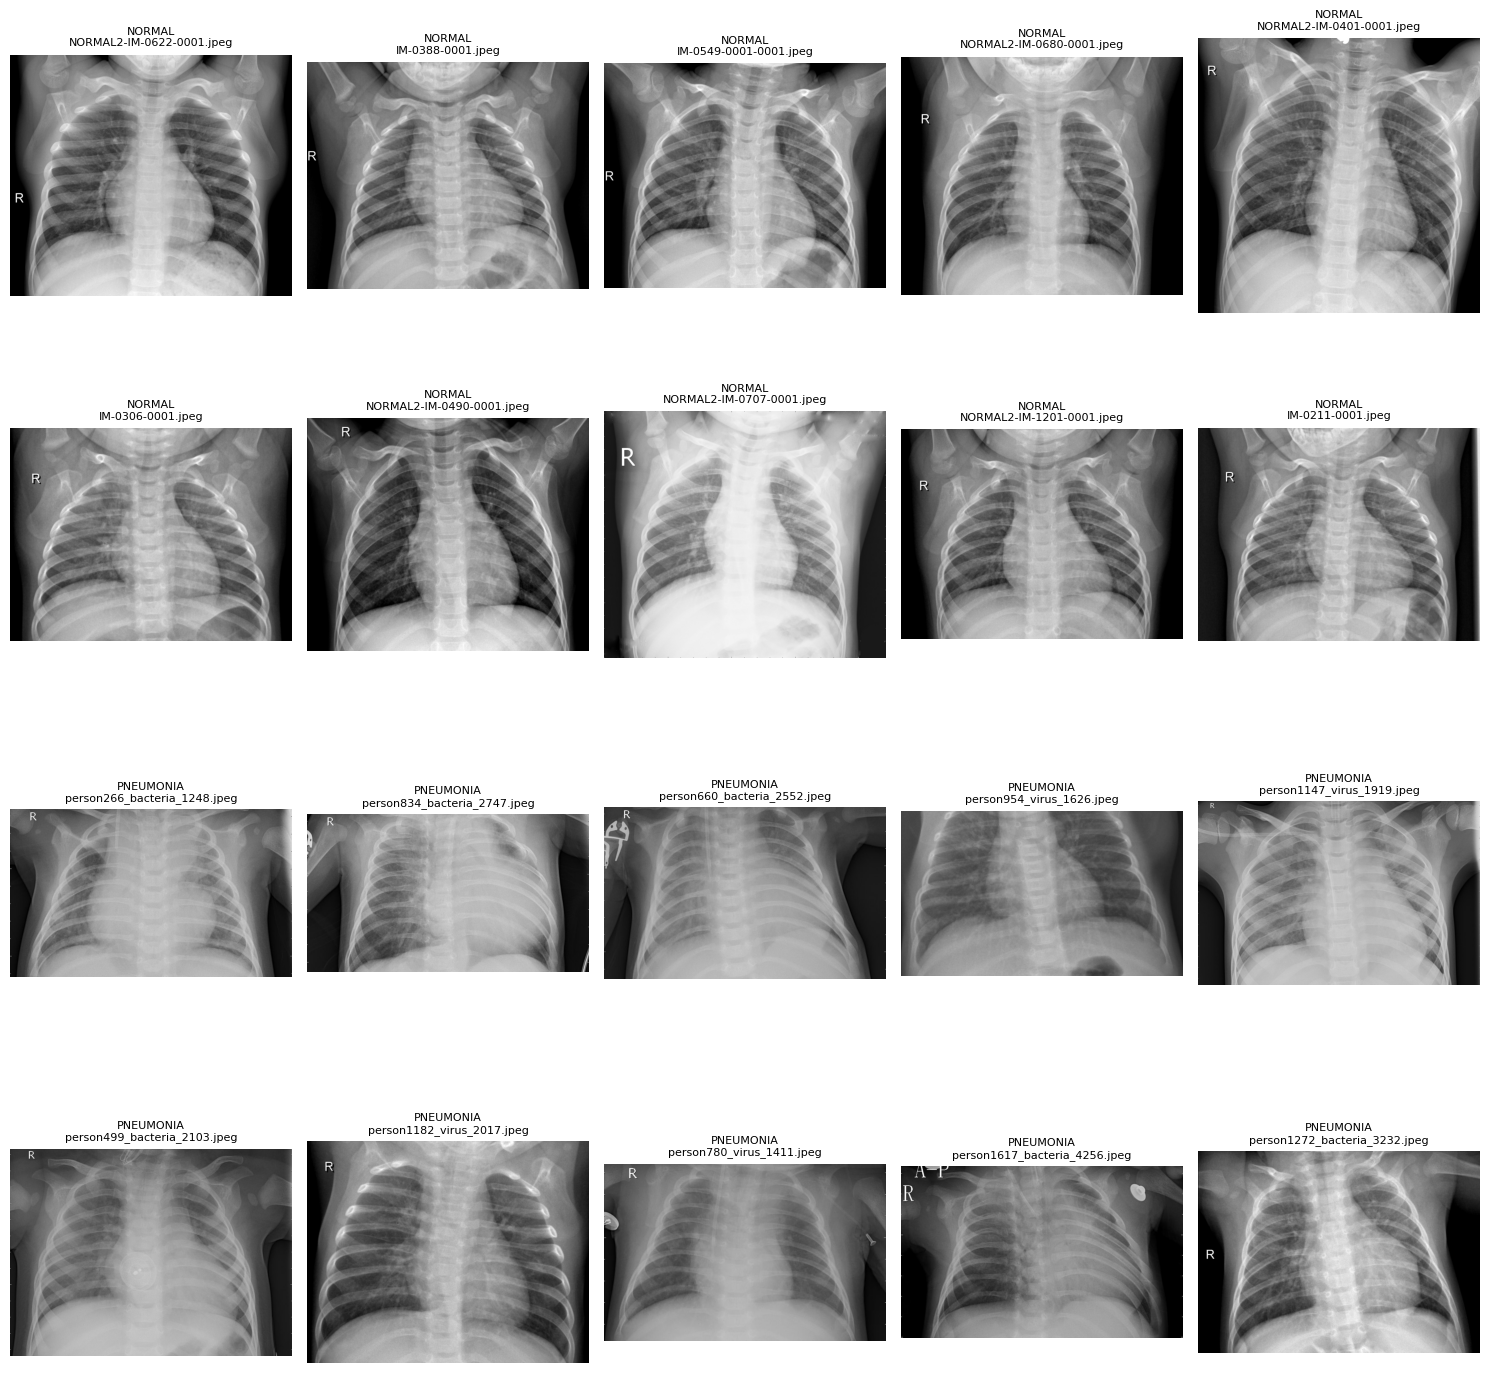

In [2]:
import os
import numpy as np
import pandas as pd
import random
import PIL
import matplotlib.pyplot as plt
import cv2

import warnings
warnings.filterwarnings('ignore')

# 경로 설정
base_path = path + '/chest_xray/train'

# 클래스 폴더 목록
class_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print( class_folders)

# 클래스별로 10장씩 이미지 추출
selected_images = []

for class_name in class_folders:
    folder_path = os.path.join(base_path, class_name)
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpeg', '.png'))]
    selected_files = random.sample(all_files, 10)
    for fname in selected_files:
        img_path = os.path.join(folder_path, fname)
        selected_images.append((img_path, class_name, fname))

# 시각화
fig, axs = plt.subplots(4, 5, figsize=(15, 15))
axs = axs.flatten()

for idx, (img_path, class_name, fname) in enumerate(selected_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axs[idx].imshow(img, cmap='gray')
    axs[idx].axis('off')
    axs[idx].set_title(f"{class_name}\n{fname}", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
def Sobel_edge( image):

    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobelx**2 + sobely**2)
    sobel = cv2.convertScaleAbs(sobel).astype(np.uint8)
    return sobel


def Canny_edge(image):
    canny = cv2.Canny(image, 50, 150)
    canny = cv2.normalize(canny, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return canny


def FFT_2D(image):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    mag = np.log(np.abs(fshift)+1)
    mag_uint8 = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return mag_uint8

def my_preprocessing(image):
    import cv2
    import numpy as np
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # Ensure grayscale image is uint8 for Canny
    gray_uint8 = gray.astype(np.uint8)

    sobel = Sobel_edge( gray_uint8)
    canny = Canny_edge( gray_uint8)
    mag = FFT_2D( gray_uint8)
    dst = np.stack([sobel, mag,  canny, gray], axis = -1)
    return dst

In [ ]:
%pip install tensorflow keras

Found 5216 images belonging to 2 classes.


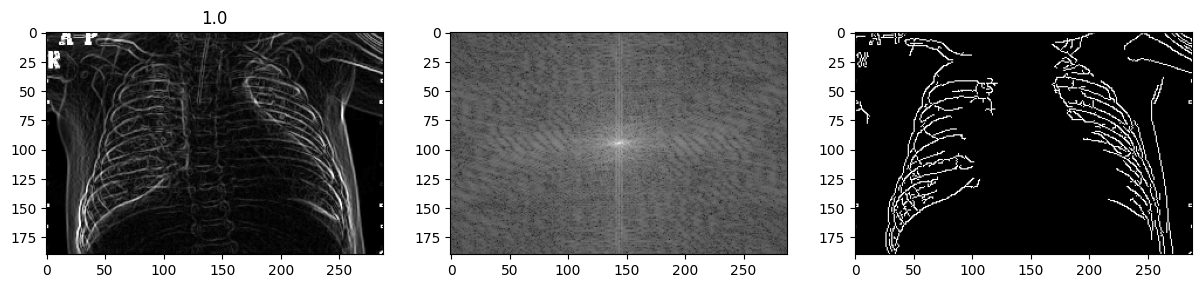

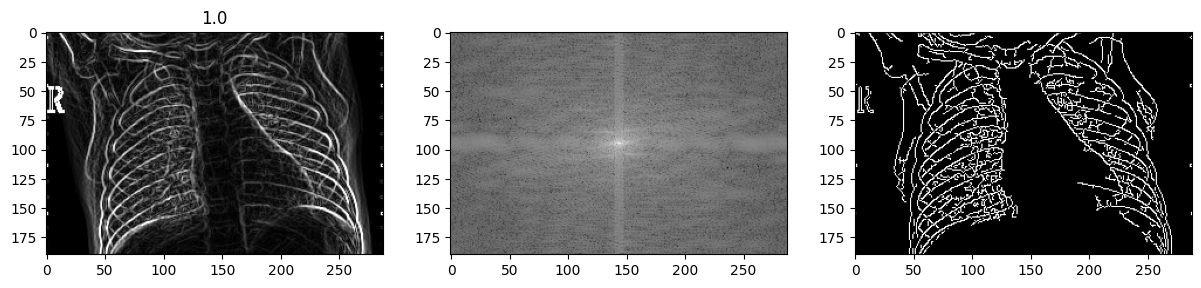

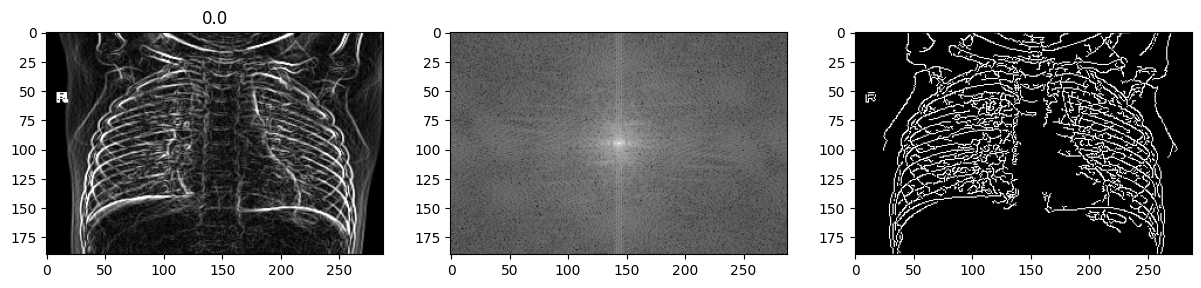

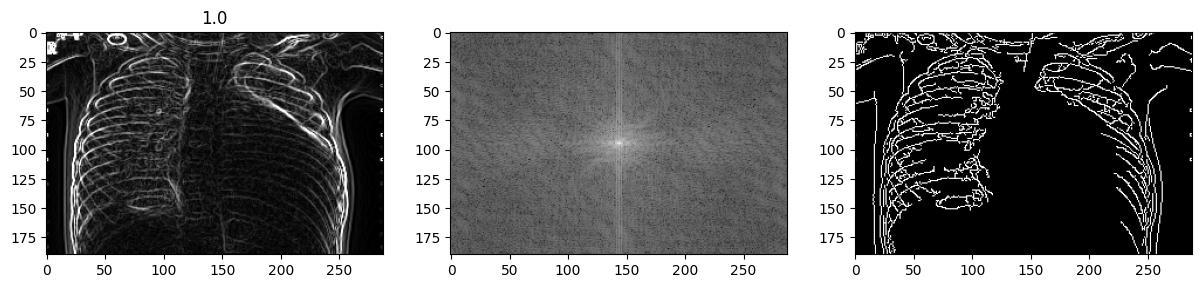

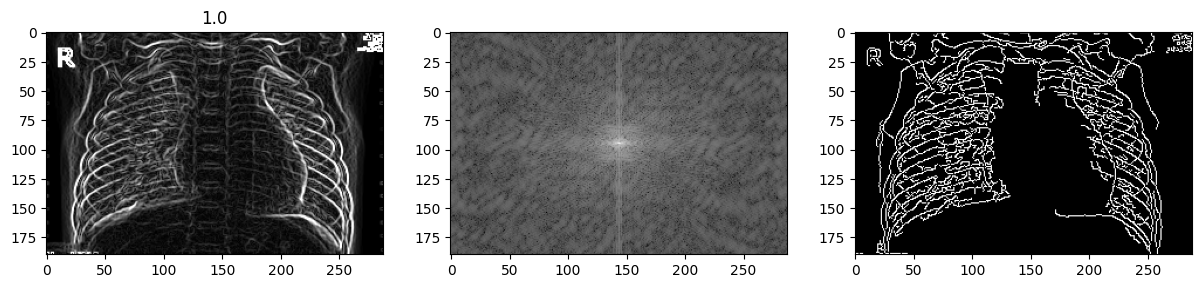

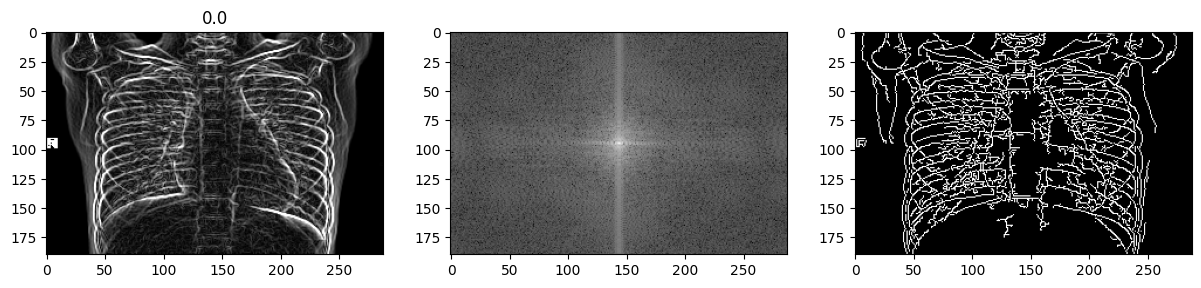

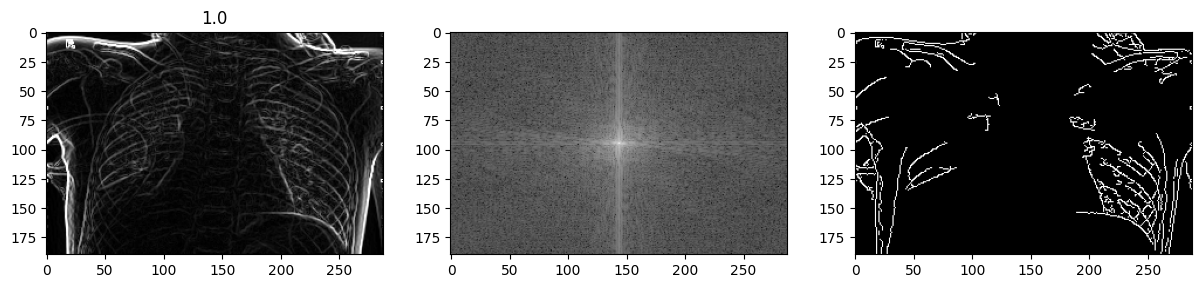

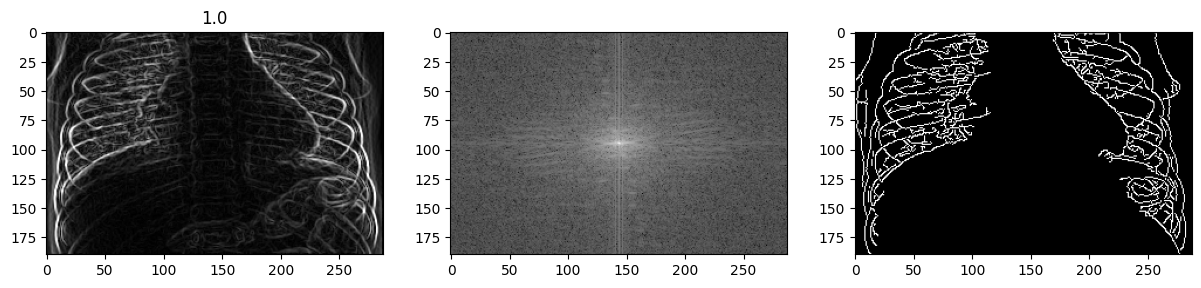

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = path + '/chest_xray/train'
training_generator = ImageDataGenerator(preprocessing_function=my_preprocessing   )  #rescale = 1/255)
train_data = training_generator.flow_from_directory(train_dir,
                                                    target_size=(190,288),
                                                    batch_size=8,
                                                    class_mode='binary')


batch_size = train_data.batch_size
x, y = next( train_data )

for j in range( batch_size ):
    image = x[j]
    plt.figure( figsize= (20, 5))
    plt.subplot( 1, 4, 1)
    plt.title(y[j])
    plt.imshow( image[:, :,  0], cmap='gray')
    plt.subplot( 1, 4, 2)
    plt.imshow( image[:, :,  1], cmap='gray')
    plt.subplot( 1, 4, 3)
    plt.imshow( image[:, :,  2], cmap='gray')
    plt.show()

In [15]:
def my_preprocessing(image):
    import cv2
    import numpy as np
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # Ensure grayscale image is uint8 for Canny
    gray_uint8 = gray.astype(np.uint8)

    sobel = Sobel_edge( gray_uint8)
    canny = Canny_edge( gray_uint8)
    mag = FFT_2D( gray_uint8)

    sobel = Sobel_edge( image)
    canny = Canny_edge( image)
    mag = FFT_2D( image)
    dst = np.stack([gray, sobel, mag,  canny], axis = -1)
    return dst

In [16]:
import os
import cv2
# 경로 설정
base_path = path + '/chest_xray/train'

# 클래스 폴더 목록
class_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
print( class_folders)

# 클래스별로  이미지 추출

train_dataset ={"images":[], "class":[]}


for class_id, class_name in enumerate(class_folders):
    folder_path = os.path.join(base_path, class_name)
    all_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpeg', '.png'))]

    for fname in all_files:
        img_path = os.path.join(folder_path, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img,  (288, 190) )
        img =  my_preprocessing(img)
        train_dataset["images"].append(img)
        train_dataset["class"].append(class_name)
else:
    print(f'총 {len(class_folders)}개의 클래스, {len(train_dataset["images"])}개의 이미지를 불러왔습니다.')
    train_dataset["images"] = np.array(train_dataset["images"])
    train_dataset["class"] = np.array(train_dataset["class"])
    print( train_dataset["images"].shape, train_dataset["class"].shape)

['NORMAL', 'PNEUMONIA']
총 2개의 클래스, 5216개의 이미지를 불러왔습니다.
(5216, 190, 288, 4) (5216,)


In [17]:
from google.colab import drive
drive.mount('/content/drive')
PATH = '/content/drive/MyDrive/data/'

Mounted at /content/drive


In [ ]:
import pickle

PATH = 'data/'
#  1. pickle로 저장하기
with open(PATH+'chest_x_ray_train_dataset.pkl', 'wb') as f:
    pickle.dump(train_dataset, f)

print(" 데이터 저장 완료: chest_x_ray_train_dataset.pkl")

#  2. pickle로 부터 불러오기
with open(PATH+'chest_x_ray_train_dataset.pkl', 'rb') as f:
    train_dataset = pickle.load(f)

print(" 불러온 데이터:", train_dataset["images"].shape)
for j  in [ 0, 1]:
    image = train_dataset["images"][j]
    plt.figure( figsize= (16, 4))
    plt.subplot( 1, 4, 1)
    plt.title(train_dataset["class"][j])
    plt.imshow( image[:, :, 0], cmap='gray')
    plt.subplot( 1, 4, 2)
    plt.imshow( image[:, :, 1], cmap='gray')
    plt.subplot( 1, 4, 3)
    plt.imshow( image[:, :, 2], cmap='gray')
    plt.subplot( 1, 4, 4)
    plt.imshow( image[:, :, 3], cmap='gray')
    plt.show()

NameError: name 'PATH' is not defined

- 테스트 데이터 셋
- base_path = path + '/chest_xray/train' 을
- base_path = path + '/chest_xray/test' 로 변경하여
- 수행한다.

In [19]:
%%time
import pickle
import numpy as np
import pandas as pd
import time
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

PATH = '/content/drive/MyDrive/data/'

# ✅ 1. pickle에서 데이터 불러오기
with open(PATH+'chest_x_ray_train_dataset.pkl', 'rb') as f:
    train_dataset = pickle.load(f)

with open(PATH+'chest_x_ray_test_dataset.pkl', 'rb') as f:
    test_dataset = pickle.load(f)

print(train_dataset["images"].shape, test_dataset["images"].shape )

chn = 2
  # -> [:,:,:,0]: original, [:,:,:,1]: Sobel, [:,:,:,2]:2DFFT, [:,:,:,3]: Canny
X_train = train_dataset["images"] [:,:,:,chn]    # shape: (5216, 288, 190)
X_test = test_dataset["images"] [:,:,:,chn]

y_train_labels = train_dataset["class"]      # 'NORMAL' or 'PNEUMONIA'
y_test_labels = test_dataset["class"]

print(X_train.shape, X_test.shape, y_train_labels.shape, y_test_labels.shape )

# ✅ 2. 이미지 정규화 (영상 값 0~255 → 0~1)
X_train  = (X_train  / 255.0).astype(np.float16)
X_test = (X_test / 255.0).astype(np.float16)

# ✅ 3. 벡터 변환 (flatten)
X_train = X_train.reshape(X_train.shape[0], -1)  # shape: (5216, 54720)
X_test = X_test.reshape(X_test.shape[0], -1)
print('->',X_train.shape, X_test.shape, y_train_labels.shape, y_test_labels.shape )

# ✅ 4. 클래스 라벨 인코딩
le = LabelEncoder()
y_train = le.fit_transform(y_train_labels)  # 'NORMAL' → 0, 'PNEUMONIA' → 1
y_test = le.transform(y_test_labels)

(5216, 190, 288, 4) (624, 190, 288, 4)
(5216, 190, 288) (624, 190, 288) (5216,) (624,)
-> (5216, 54720) (624, 54720) (5216,) (624,)
CPU times: user 3.3 s, sys: 5.95 s, total: 9.25 s
Wall time: 30.5 s


In [21]:
%%time
import pickle
import numpy as np
import pandas as pd
import time
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from pprint import pprint


# ✅ 6. 분류기 정의
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "kNN": KNeighborsClassifier(n_neighbors=5),
#   "SVM": SVC(kernel='poly',degree=3), # --> kernel = linear?? sigmoid(성능 낮음)
#    "Decision Tree": DecisionTreeClassifier(),
#    "Random Forest": RandomForestClassifier(n_estimators=100),
#    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# ✅ 7. 성능 평가 저장소
results = []

# ✅ 8. 분류 및 성능 평가
for name, clf in classifiers.items():
    print( f"{name} 모델 학습 중...", end=" ")
    start_time = datetime.now()
    print("시작 시간:", start_time.strftime("%Y-%m-%d %H:%M:%S"))
    clf.fit(X_train, y_train)
    end_time = datetime.now()
    print("종료 시간:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
    # 시간 차이 계산 (분 단위로 출력)
    elapsed_time = end_time - start_time
    elapsed_minutes = elapsed_time.total_seconds() / 60
    print(f"실행 시간 차이: {elapsed_minutes:.2f} 분")

    print("테스트...", end=" ")
    y_pred = clf.predict(X_test)
    print("성능 ..",  end="\n")
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    pprint( results)
else:
    print("✅ 분류 및 성능 평가 완료!")

# ✅ 9. 성능 비교 출력
df_results = pd.DataFrame(results)
print("\n📊 분류 성능 비교:")
print(df_results.sort_values("F1 Score", ascending=False))

# ✅ 10. pickle로 저장하기
with open(PATH+'chest_x_ray_classification_fulldataset_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("✅ 데이터 저장 완료: chest_x_ray_classification_fulldataset_results.pkl")


Logistic Regression 모델 학습 중... 테스트... 성능 ..
[{'Accuracy': 0.6650641025641025,
  'F1 Score': 0.7825182101977107,
  'Model': 'Logistic Regression',
  'Precision': 0.658493870402802,
  'Recall': 0.9641025641025641}]
kNN 모델 학습 중... 테스트... 성능 ..
[{'Accuracy': 0.6650641025641025,
  'F1 Score': 0.7825182101977107,
  'Model': 'Logistic Regression',
  'Precision': 0.658493870402802,
  'Recall': 0.9641025641025641},
 {'Accuracy': 0.6298076923076923,
  'F1 Score': 0.7678391959798995,
  'Model': 'kNN',
  'Precision': 0.631404958677686,
  'Recall': 0.9794871794871794}]
✅ 분류 및 성능 평가 완료!

📊 분류 성능 비교:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.665064   0.658494  0.964103  0.782518
1                  kNN  0.629808   0.631405  0.979487  0.767839
✅ 데이터 저장 완료: chest_x_ray_classification_fulldataset_results.pkl
CPU times: user 1min 14s, sys: 4.18 s, total: 1min 18s
Wall time: 53.7 s
